In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
ROOT = Path.cwd().parent.parent

# Path input utama
MANIFEST_STRICT_PATH = ROOT / "output" / "split_strict" / "manifest_strict.csv"

# Optional: kalau ada
VAD_DROP_PATH = ROOT / "output" / "preprocessing" / "vad" / "vad_drop.csv"
VAD_REPORT_PATH = ROOT / "output" / "preprocessing" / "vad" / "vad_report.csv"

# Folder output lampiran
APPENDIX_DIR = ROOT / "code" / "V2" / "outputs" / "output_lampiran_4.1.2"
TABLE_DIR = APPENDIX_DIR / "tables"
FIGURE_DIR = APPENDIX_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIT_COLS = [
    "extraversion",
    "neuroticism",
    "agreeableness",
    "conscientiousness",
    "openness",
]

AVG_TRAIT_COL = "avg_trait"

print("Manifest strict:", MANIFEST_STRICT_PATH)
print("Output table dir:", TABLE_DIR)
print("Output figure dir:", FIGURE_DIR)

Manifest strict: e:\tugas-akhir-qiqi\output\split_strict\manifest_strict.csv
Output table dir: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables
Output figure dir: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures


In [7]:
# =========================
# BLOCK 2: LOAD MANIFEST & VALIDATE COLUMNS
# =========================

df = pd.read_csv(MANIFEST_STRICT_PATH)

print("Shape manifest_strict:", df.shape)
display(df.head())

required_cols = [
    "clip_id",
    "group_id",
    "split_official",
    "split_strict",
    *TRAIT_COLS,
]

missing_required = [c for c in required_cols if c not in df.columns]

if missing_required:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_required}")

# Jika avg_trait belum ada, hitung ulang
if AVG_TRAIT_COL not in df.columns:
    df[AVG_TRAIT_COL] = df[TRAIT_COLS].mean(axis=1)
    print("avg_trait belum ada, sudah dihitung ulang dari 5 trait.")

print("Kolom tersedia:")
print(df.columns.tolist())

print("\nSplit official:")
display(df["split_official"].value_counts(dropna=False))

print("\nSplit strict:")
display(df["split_strict"].value_counts(dropna=False))

Shape manifest_strict: (9974, 14)


,clip_id,group_id,audio_out,gender,ethnicity,age_group,avg_trait,extraversion,neuroticism,agreeableness,conscientiousness,openness,split_official,split_strict
0,-10-QQDO_ME.001,-10-QQDO_ME,output/preprocessing/preprocessed_full/-10-QQD...,2,2,5,0.543498,0.532710,0.416667,0.549451,0.563107,0.655556,test,test
1,-10-QQDO_ME.002,-10-QQDO_ME,output/preprocessing/preprocessed_full/-10-QQD...,2,2,5,0.603820,0.579439,0.531250,0.670330,0.582524,0.655556,test,test
2,-10-QQDO_ME.005,-10-QQDO_ME,output/preprocessing/preprocessed_full/-10-QQD...,2,2,5,0.569252,0.532710,0.552083,0.516484,0.611650,0.633333,test,test
3,-IK--4uz5ZY.000,-IK--4uz5ZY,output/preprocessing/preprocessed_full/-IK--4u...,2,2,5,0.602967,0.579439,0.562500,0.604396,0.679612,0.588889,train,test
4,-IK--4uz5ZY.002,-IK--4uz5ZY,output/preprocessing/preprocessed_full/-IK--4u...,2,2,5,0.586361,0.542056,0.635417,0.527473,0.660194,0.566667,train,test


Kolom tersedia:
['clip_id', 'group_id', 'audio_out', 'gender', 'ethnicity', 'age_group', 'avg_trait', 'extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness', 'split_official', 'split_strict']

Split official:


split_official
train    5988
val      1994
test     1992
Name: count, dtype: int64


Split strict:


split_strict
train    5936
test     2039
val      1999
Name: count, dtype: int64

In [8]:
# =========================
# BLOCK 3: APPENDIX 23 - STRICT SPLIT LABEL STATS
# =========================

label_cols = TRAIT_COLS + [AVG_TRAIT_COL]

strict_label_stats = (
    df.groupby("split_strict")[label_cols]
      .agg(["count", "mean", "std", "min", "median", "max"])
      .round(6)
)

display(strict_label_stats)

# Format long agar enak masuk Word
rows = []
for split, g in df.groupby("split_strict"):
    for trait in label_cols:
        rows.append({
            "Split": split,
            "Trait": trait,
            "Count": len(g),
            "Mean": g[trait].mean(),
            "Std": g[trait].std(),
            "Min": g[trait].min(),
            "Median": g[trait].median(),
            "Max": g[trait].max(),
        })

strict_label_stats_long = pd.DataFrame(rows).round(6)

out_path = TABLE_DIR / "lampiran_23_distribusi_label_bigfive_strict_split.csv"
strict_label_stats_long.to_csv(out_path, index=False)

print("Saved:", out_path)
display(strict_label_stats_long)

extraversion                                                    \
                    count      mean       std       min    median       max   
split_strict                                                                  
test                 2039  0.470627  0.154427  0.009346  0.467290  0.925234   
train                5936  0.479521  0.150189  0.000000  0.485981  1.000000   
val                  1999  0.475144  0.149135  0.018692  0.476636  0.887850   

             neuroticism                                ...  openness  \
                   count      mean       std       min  ...       std   
split_strict                                            ...             
test                2039  0.513191  0.159383  0.020833  ...  0.149040   
train               5936  0.523430  0.150915  0.000000  ...  0.144943   
val                 1999  0.522636  0.150167  0.020833  ...  0.144157   

                                           avg_trait                      \
                   min    median       max     count      mean       std   
split_strict                                                               
test          0.111111  0.566667  0.977778      2039  0.521233  0.133502   
train         0.000000  0.577778  1.000000      5936  0.530150  0.126996   
val           0.133333  0.566667  0.977778      1999  0.527767  0.125254   

                                            
                   min    median       max  
split_strict                                
test          0.116503  0.527802  0.923902  
train         0.049752  0.535753  0.908998  
val           0.086161  0.536419  0.857350  

[3 rows x 36 columns]

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_23_distribusi_label_bigfive_strict_split.csv


,Split,Trait,Count,Mean,Std,Min,Median,Max
0,test,extraversion,2039,0.470627,0.154427,0.009346,0.467290,0.925234
1,test,neuroticism,2039,0.513191,0.159383,0.020833,0.520833,1.000000
2,test,agreeableness,2039,0.543479,0.138344,0.109890,0.549451,0.912088
3,test,conscientiousness,2039,0.518315,0.159164,0.038835,0.524272,0.980583
4,test,openness,2039,0.560553,0.149040,0.111111,0.566667,0.977778
5,test,avg_trait,2039,0.521233,0.133502,0.116503,0.527802,0.923902
6,train,extraversion,5936,0.479521,0.150189,0.000000,0.485981,1.000000
7,train,neuroticism,5936,0.523430,0.150915,0.000000,0.531250,0.979167
8,train,agreeableness,5936,0.552451,0.132958,0.000000,0.560440,1.000000
9,train,conscientiousness,5936,0.526184,0.154187,0.038835,0.533981,1.000000


In [9]:
# =========================
# BLOCK 3B: EXPORT TEXT-TO-TABLE WORD FORMAT
# Separator: semicolon (;)
# =========================

txt_path = TABLE_DIR / "lampiran_23_distribusi_label_bigfive_strict_split_word.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(";".join(strict_label_stats_long.columns) + "\n")
    for _, row in strict_label_stats_long.iterrows():
        f.write(";".join(str(row[col]) for col in strict_label_stats_long.columns) + "\n")

print("Saved Word text-to-table:", txt_path)

Saved Word text-to-table: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_23_distribusi_label_bigfive_strict_split_word.txt


In [10]:
# =========================
# BLOCK 4: APPENDIX 27 - STRICT LABEL MEAN DRIFT SUMMARY
# =========================

mean_by_split = df.groupby("split_strict")[label_cols].mean().T.round(6)

# Pastikan urutan kolom enak dibaca
preferred_order = ["train", "validation", "val", "test"]
existing_order = [s for s in preferred_order if s in mean_by_split.columns]
remaining = [s for s in mean_by_split.columns if s not in existing_order]
mean_by_split = mean_by_split[existing_order + remaining]

mean_by_split["max_mean_diff"] = mean_by_split.max(axis=1) - mean_by_split.min(axis=1)
mean_by_split = mean_by_split.round(6)

out_path = TABLE_DIR / "lampiran_27_ringkasan_drift_mean_label_strict_split.csv"
mean_by_split.to_csv(out_path)

print("Saved:", out_path)
display(mean_by_split)

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_27_ringkasan_drift_mean_label_strict_split.csv


split_strict,train,val,test,max_mean_diff
extraversion,0.479521,0.475144,0.470627,0.008894
neuroticism,0.523430,0.522636,0.513191,0.010239
agreeableness,0.552451,0.548230,0.543479,0.008972
conscientiousness,0.526184,0.526297,0.518315,0.007982
openness,0.569164,0.566528,0.560553,0.008611
avg_trait,0.530150,0.527767,0.521233,0.008917


In [11]:
# =========================
# BLOCK 4B: EXPORT DRIFT SUMMARY TO WORD TEXT FORMAT
# =========================

word_df = mean_by_split.reset_index().rename(columns={"index": "Trait"})

txt_path = TABLE_DIR / "lampiran_27_ringkasan_drift_mean_label_strict_split_word.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(";".join(word_df.columns) + "\n")
    for _, row in word_df.iterrows():
        f.write(";".join(str(row[col]) for col in word_df.columns) + "\n")

print("Saved Word text-to-table:", txt_path)
display(word_df)

Saved Word text-to-table: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_27_ringkasan_drift_mean_label_strict_split_word.txt


split_strict,Trait,train,val,test,max_mean_diff
0,extraversion,0.479521,0.475144,0.470627,0.008894
1,neuroticism,0.523430,0.522636,0.513191,0.010239
2,agreeableness,0.552451,0.548230,0.543479,0.008972
3,conscientiousness,0.526184,0.526297,0.518315,0.007982
4,openness,0.569164,0.566528,0.560553,0.008611
5,avg_trait,0.530150,0.527767,0.521233,0.008917


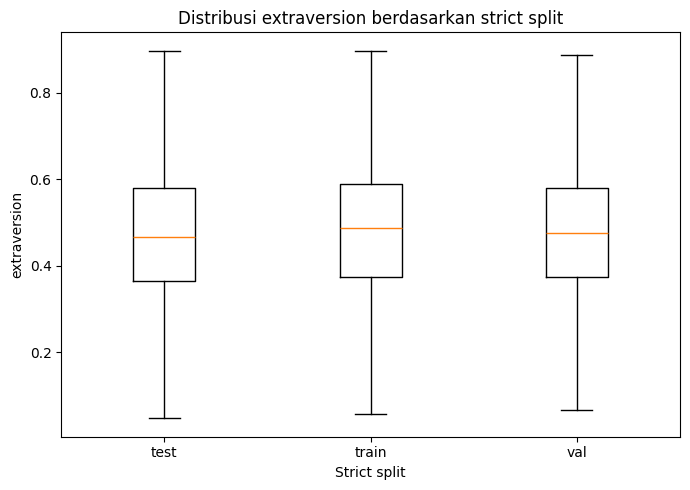

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures\strict_split_boxplot_extraversion.png


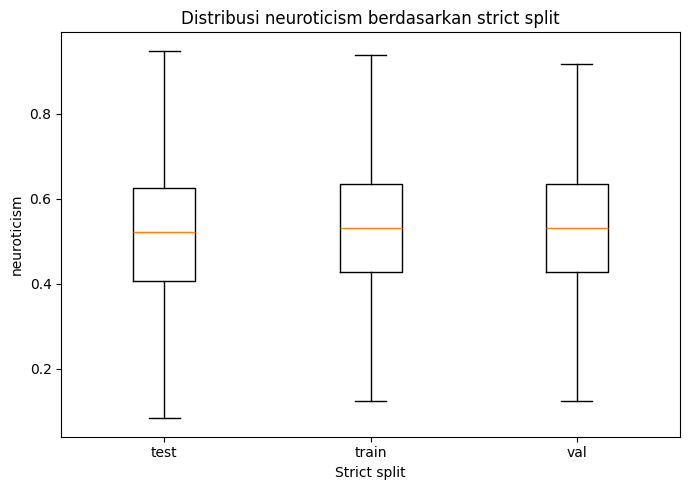

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures\strict_split_boxplot_neuroticism.png


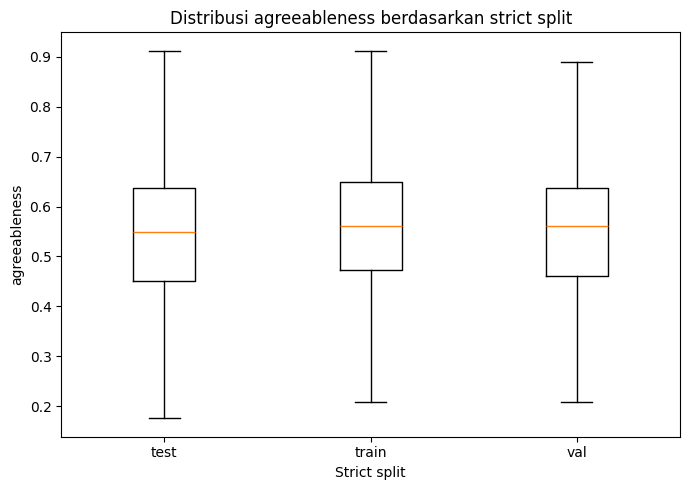

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures\strict_split_boxplot_agreeableness.png


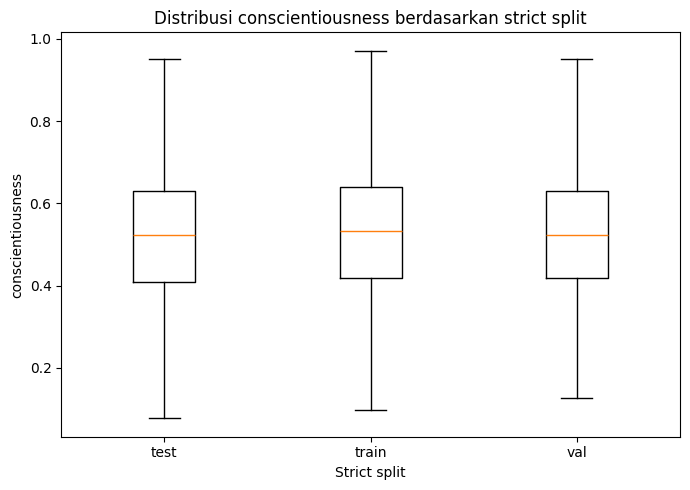

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures\strict_split_boxplot_conscientiousness.png


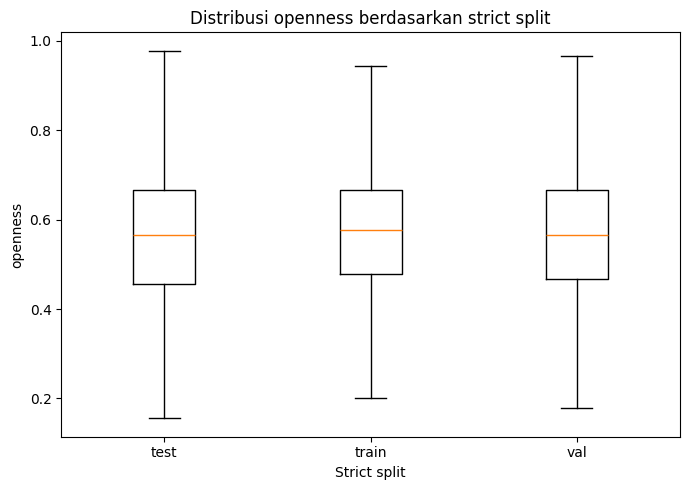

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures\strict_split_boxplot_openness.png


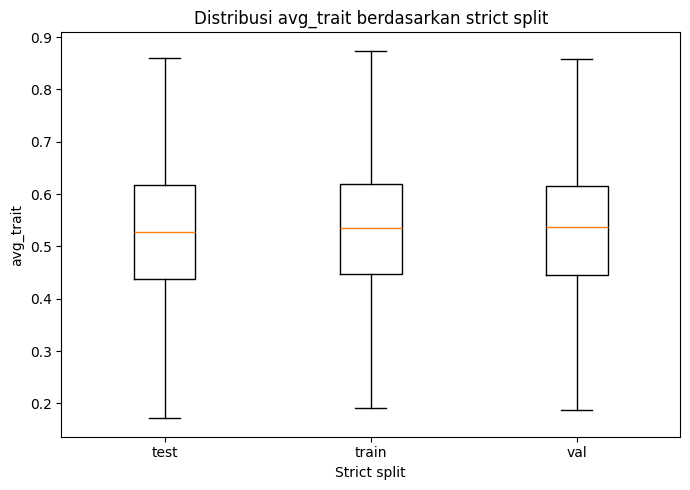

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures\strict_split_boxplot_avg_trait.png


In [13]:
# =========================
# BLOCK 5: FIGURE - STRICT LABEL BOXPLOT BY SPLIT
# =========================

for trait in label_cols:
    plt.figure(figsize=(7, 5))
    
    data = []
    labels = []
    for split, g in df.groupby("split_strict"):
        data.append(g[trait].dropna().values)
        labels.append(split)

    plt.boxplot(data, tick_labels=labels, showfliers=False)
    plt.title(f"Distribusi {trait} berdasarkan strict split")
    plt.xlabel("Strict split")
    plt.ylabel(trait)
    plt.tight_layout()

    out_path = FIGURE_DIR / f"strict_split_boxplot_{trait}.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print("Saved:", out_path)

In [14]:
# =========================
# BLOCK 6: APPENDIX 24 - OFFICIAL VS STRICT SPLIT SIZE
# =========================

def split_size_summary(data, split_col, label):
    rows = []
    for split, g in data.groupby(split_col):
        rows.append({
            "Protocol": label,
            "Split": split,
            "Clip_count": len(g),
            "Group_count": g["group_id"].nunique(),
            "Clip_prop": len(g) / len(data),
            "Group_prop": g["group_id"].nunique() / data["group_id"].nunique(),
        })
    return pd.DataFrame(rows)

official_size = split_size_summary(df, "split_official", "official_after_vad_drop")
strict_size = split_size_summary(df, "split_strict", "strict_group_based")

split_size_compare = pd.concat([official_size, strict_size], ignore_index=True)
split_size_compare = split_size_compare.round(6)

out_path = TABLE_DIR / "lampiran_24_perbandingan_ukuran_official_vs_strict.csv"
split_size_compare.to_csv(out_path, index=False)

print("Saved:", out_path)
display(split_size_compare)

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_24_perbandingan_ukuran_official_vs_strict.csv


,Protocol,Split,Clip_count,Group_count,Clip_prop,Group_prop
0,official_after_vad_drop,test,1992,1451,0.199719,0.475115
1,official_after_vad_drop,train,5988,2620,0.600361,0.857891
2,official_after_vad_drop,val,1994,1480,0.199920,0.484610
3,strict_group_based,test,2039,617,0.204432,0.202030
4,strict_group_based,train,5936,1829,0.595147,0.598887
5,strict_group_based,val,1999,608,0.200421,0.199083


In [15]:
# =========================
# BLOCK 6B: EXPORT SPLIT SIZE TO WORD TEXT FORMAT
# =========================

txt_path = TABLE_DIR / "lampiran_24_perbandingan_ukuran_official_vs_strict_word.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(";".join(split_size_compare.columns) + "\n")
    for _, row in split_size_compare.iterrows():
        f.write(";".join(str(row[col]) for col in split_size_compare.columns) + "\n")

print("Saved Word text-to-table:", txt_path)

Saved Word text-to-table: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_24_perbandingan_ukuran_official_vs_strict_word.txt


In [16]:
# =========================
# BLOCK 7: APPENDIX 25 - GROUP_ID OVERLAP MATRIX
# =========================

def group_overlap_matrix(data, split_col):
    splits = sorted(data[split_col].dropna().unique().tolist())
    split_to_groups = {
        split: set(data.loc[data[split_col] == split, "group_id"].dropna())
        for split in splits
    }
    
    mat = pd.DataFrame(index=splits, columns=splits, dtype=int)
    for s1 in splits:
        for s2 in splits:
            mat.loc[s1, s2] = len(split_to_groups[s1].intersection(split_to_groups[s2]))
    return mat.astype(int)

official_group_overlap = group_overlap_matrix(df, "split_official")
strict_group_overlap = group_overlap_matrix(df, "split_strict")

official_out = TABLE_DIR / "lampiran_25a_overlap_group_id_official_split.csv"
strict_out = TABLE_DIR / "lampiran_25b_overlap_group_id_strict_split.csv"

official_group_overlap.to_csv(official_out)
strict_group_overlap.to_csv(strict_out)

print("Official group overlap:")
display(official_group_overlap)
print("Saved:", official_out)

print("\nStrict group overlap:")
display(strict_group_overlap)
print("Saved:", strict_out)

Official group overlap:


,test,train,val
test,1451,1198,687
train,1198,2620,1220
val,687,1220,1480


Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_25a_overlap_group_id_official_split.csv

Strict group overlap:


,test,train,val
test,617,0,0
train,0,1829,0
val,0,0,608


Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_25b_overlap_group_id_strict_split.csv


In [17]:
# =========================
# BLOCK 7B: PAIRWISE GROUP OVERLAP SUMMARY
# =========================

def pairwise_group_overlap_summary(data, split_col, protocol_name):
    splits = sorted(data[split_col].dropna().unique().tolist())
    split_to_groups = {
        split: set(data.loc[data[split_col] == split, "group_id"].dropna())
        for split in splits
    }
    
    rows = []
    for i, s1 in enumerate(splits):
        for s2 in splits[i+1:]:
            overlap = split_to_groups[s1].intersection(split_to_groups[s2])
            rows.append({
                "Protocol": protocol_name,
                "Split_A": s1,
                "Split_B": s2,
                "Overlap_group_id_count": len(overlap),
                "Example_overlap_group_id": ", ".join(list(sorted(overlap))[:5]) if overlap else "",
            })
    return pd.DataFrame(rows)

official_pairwise_overlap = pairwise_group_overlap_summary(
    df, "split_official", "official_after_vad_drop"
)

strict_pairwise_overlap = pairwise_group_overlap_summary(
    df, "split_strict", "strict_group_based"
)

pairwise_overlap = pd.concat(
    [official_pairwise_overlap, strict_pairwise_overlap],
    ignore_index=True
)

out_path = TABLE_DIR / "lampiran_25c_pairwise_overlap_group_id_official_vs_strict.csv"
pairwise_overlap.to_csv(out_path, index=False)

print("Saved:", out_path)
display(pairwise_overlap)

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_25c_pairwise_overlap_group_id_official_vs_strict.csv


,Protocol,Split_A,Split_B,Overlap_group_id_count,Example_overlap_group_id
0,official_after_vad_drop,test,train,1198,"--Ymqszjv54, -6otZ7M-Mro, -8asrRvfJWA, -DOqN0d..."
1,official_after_vad_drop,test,val,687,"-6otZ7M-Mro, -8asrRvfJWA, -DOqN0d8KHw, -N6QKrb..."
2,official_after_vad_drop,train,val,1220,"-6otZ7M-Mro, -8asrRvfJWA, -9BZ8A9U7TE, -AmMDnV..."
3,strict_group_based,test,train,0,
4,strict_group_based,test,val,0,
5,strict_group_based,train,val,0,


In [18]:
# =========================
# BLOCK 7C: EXPORT PAIRWISE OVERLAP TO WORD TEXT FORMAT
# =========================

txt_path = TABLE_DIR / "lampiran_25c_pairwise_overlap_group_id_official_vs_strict_word.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(";".join(pairwise_overlap.columns) + "\n")
    for _, row in pairwise_overlap.iterrows():
        f.write(";".join(str(row[col]) for col in pairwise_overlap.columns) + "\n")

print("Saved Word text-to-table:", txt_path)

Saved Word text-to-table: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_25c_pairwise_overlap_group_id_official_vs_strict_word.txt


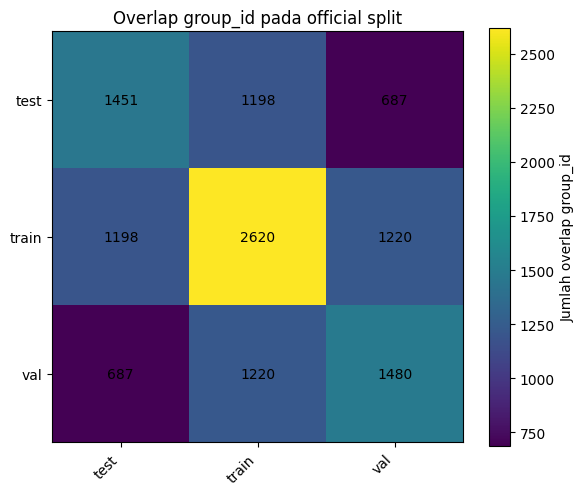

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures\group_overlap_official_split.png


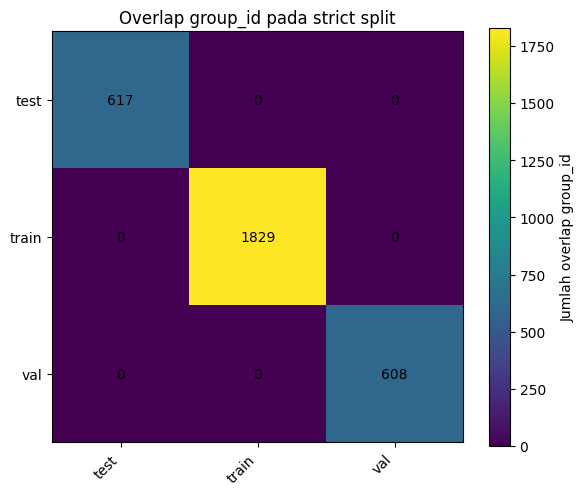

Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\figures\group_overlap_strict_split.png


In [19]:
# =========================
# BLOCK 8: FIGURE - GROUP OVERLAP HEATMAP
# =========================

def plot_overlap_heatmap(mat, title, out_path):
    plt.figure(figsize=(6, 5))
    plt.imshow(mat.values)
    plt.xticks(range(len(mat.columns)), mat.columns, rotation=45, ha="right")
    plt.yticks(range(len(mat.index)), mat.index)
    plt.title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, str(mat.iloc[i, j]), ha="center", va="center")

    plt.colorbar(label="Jumlah overlap group_id")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()
    print("Saved:", out_path)

plot_overlap_heatmap(
    official_group_overlap,
    "Overlap group_id pada official split",
    FIGURE_DIR / "group_overlap_official_split.png"
)

plot_overlap_heatmap(
    strict_group_overlap,
    "Overlap group_id pada strict split",
    FIGURE_DIR / "group_overlap_strict_split.png"
)

In [20]:
# =========================
# BLOCK 9: APPENDIX 26 - DEMOGRAPHIC DISTRIBUTION OFFICIAL VS STRICT
# =========================

demo_cols = [c for c in ["gender", "ethnicity", "age_group"] if c in df.columns]
print("Demographic columns found:", demo_cols)

def categorical_distribution(data, split_col, cat_col, protocol_name):
    counts = (
        data.groupby([split_col, cat_col])
            .size()
            .reset_index(name="Count")
    )
    totals = (
        data.groupby(split_col)
            .size()
            .reset_index(name="Total")
    )
    out = counts.merge(totals, on=split_col, how="left")
    out["Prop"] = out["Count"] / out["Total"]
    out.insert(0, "Protocol", protocol_name)
    out = out.rename(columns={split_col: "Split", cat_col: "Category"})
    out.insert(2, "Variable", cat_col)
    return out

demo_tables = []

for col in demo_cols:
    demo_tables.append(categorical_distribution(df, "split_official", col, "official_after_vad_drop"))
    demo_tables.append(categorical_distribution(df, "split_strict", col, "strict_group_based"))

if demo_tables:
    demo_compare = pd.concat(demo_tables, ignore_index=True).round(6)
else:
    demo_compare = pd.DataFrame()

out_path = TABLE_DIR / "lampiran_26_distribusi_demografi_official_vs_strict.csv"
demo_compare.to_csv(out_path, index=False)

print("Saved:", out_path)
display(demo_compare)

Demographic columns found: ['gender', 'ethnicity', 'age_group']
Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_26_distribusi_demografi_official_vs_strict.csv


,Protocol,Split,Variable,Category,Count,Total,Prop
0,official_after_vad_drop,test,gender,1,886,1992,0.444779
1,official_after_vad_drop,test,gender,2,1106,1992,0.555221
2,official_after_vad_drop,train,gender,1,2732,5988,0.456246
3,official_after_vad_drop,train,gender,2,3256,5988,0.543754
4,official_after_vad_drop,val,gender,1,916,1994,0.459378
...,...,...,...,...,...,...,...
69,strict_group_based,val,age_group,4,360,1999,0.180090
70,strict_group_based,val,age_group,5,1007,1999,0.503752
71,strict_group_based,val,age_group,6,487,1999,0.243622
72,strict_group_based,val,age_group,7,67,1999,0.033517


In [21]:
# =========================
# BLOCK 9B: EXPORT DEMO DISTRIBUTION TO WORD TEXT FORMAT
# =========================

txt_path = TABLE_DIR / "lampiran_26_distribusi_demografi_official_vs_strict_word.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(";".join(demo_compare.columns) + "\n")
    for _, row in demo_compare.iterrows():
        f.write(";".join(str(row[col]) for col in demo_compare.columns) + "\n")

print("Saved Word text-to-table:", txt_path)

Saved Word text-to-table: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_26_distribusi_demografi_official_vs_strict_word.txt


In [22]:
# =========================
# BLOCK 10: APPENDIX 28 - VAD DROP FINAL SUMMARY
# =========================

if VAD_DROP_PATH.exists():
    vad_drop = pd.read_csv(VAD_DROP_PATH)
    print("Shape vad_drop:", vad_drop.shape)
    display(vad_drop.head())

    # Ringkasan umum semua kolom numerik
    numeric_cols = vad_drop.select_dtypes(include=[np.number]).columns.tolist()

    if numeric_cols:
        vad_drop_numeric_summary = (
            vad_drop[numeric_cols]
            .describe()
            .T
            .round(6)
            .reset_index()
            .rename(columns={"index": "Metric"})
        )
    else:
        vad_drop_numeric_summary = pd.DataFrame()

    # Ringkasan reason kalau ada
    if "reason" in vad_drop.columns:
        vad_drop_reason = (
            vad_drop["reason"]
            .value_counts(dropna=False)
            .reset_index()
        )
        vad_drop_reason.columns = ["Reason", "Count"]
    else:
        vad_drop_reason = pd.DataFrame()

    out_summary = TABLE_DIR / "lampiran_28a_vad_drop_numeric_summary.csv"
    out_reason = TABLE_DIR / "lampiran_28b_vad_drop_reason_summary.csv"

    vad_drop_numeric_summary.to_csv(out_summary, index=False)
    vad_drop_reason.to_csv(out_reason, index=False)

    print("Saved:", out_summary)
    display(vad_drop_numeric_summary)

    print("Saved:", out_reason)
    display(vad_drop_reason)

else:
    print("vad_drop.csv tidak ditemukan:", VAD_DROP_PATH)

Shape vad_drop: (26, 5)


,clip_id,speech_sec,voiced_ratio,n_seg,reason
0,521sm7CTyfg.000,0.668,0.044533,1,too_little_speech
1,KRo-x2uoHUg.003,0.000,0.000000,0,too_little_speech
2,Lz3hYPF6aIM.000,0.220,0.014667,1,too_little_speech
3,OXkDmd3nA94.000,0.888,0.059200,2,too_little_speech
4,OXkDmd3nA94.002,0.440,0.029333,2,too_little_speech


Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_28a_vad_drop_numeric_summary.csv


,Metric,count,mean,std,min,25%,50%,75%,max
0,speech_sec,26.0,0.697769,0.546363,0.0,0.3240,0.506000,1.1280,1.682000
1,voiced_ratio,26.0,0.046518,0.036424,0.0,0.0216,0.033733,0.0752,0.112133
2,n_seg,26.0,1.500000,1.104536,0.0,1.0000,1.000000,2.0000,5.000000


Saved: e:\tugas-akhir-qiqi\code\V2\outputs\output_lampiran_4.1.2\tables\lampiran_28b_vad_drop_reason_summary.csv


,Reason,Count
0,too_little_speech,26


In [ ]:
# =========================
# BLOCK 10B FAST + VERBOSE: VAD REPORT SUMMARY IF AVAILABLE
# =========================

import time

print("=== START BLOCK 10B: VAD REPORT SUMMARY ===")
start_all = time.time()

print("[1/7] Cek path VAD report...")
print("Path:", VAD_REPORT_PATH)
print("Exists:", VAD_REPORT_PATH.exists())

if VAD_REPORT_PATH.exists():
    size_mb = VAD_REPORT_PATH.stat().st_size / (1024 * 1024)
    print(f"File size: {size_mb:.2f} MB")

    needed_cols = ["speech_sec", "voiced_ratio", "n_seg"]

    print("\n[2/7] Membaca header CSV...")
    t0 = time.time()
    header_cols = pd.read_csv(VAD_REPORT_PATH, nrows=0).columns.tolist()
    print(f"Header loaded in {time.time() - t0:.2f} sec")
    print("Jumlah kolom:", len(header_cols))
    print("Kolom tersedia:", header_cols)

    use_cols = [c for c in needed_cols if c in header_cols]
    print("\n[3/7] Kolom VAD yang akan dipakai:", use_cols)

    if not use_cols:
        raise ValueError(f"Tidak ada kolom VAD yang ditemukan. Kolom tersedia: {header_cols}")

    print("\n[4/7] Membaca hanya kolom VAD yang dibutuhkan...")
    t0 = time.time()
    vad_report = pd.read_csv(VAD_REPORT_PATH, usecols=use_cols)
    print(f"CSV selected columns loaded in {time.time() - t0:.2f} sec")
    print("Shape vad_report selected columns:", vad_report.shape)

    print("\nPreview data:")
    display(vad_report.head())

    print("\n[5/7] Menghitung statistik describe...")
    t0 = time.time()
    vad_report_summary = (
        vad_report[use_cols]
        .describe()
        .T
        .round(6)
        .reset_index()
        .rename(columns={"index": "Metric"})
    )
    print(f"Describe computed in {time.time() - t0:.2f} sec")

    print("\nHasil summary:")
    display(vad_report_summary)

    print("\n[6/7] Menyimpan summary CSV...")
    t0 = time.time()
    out_path = TABLE_DIR / "lampiran_28c_vad_report_summary.csv"
    vad_report_summary.to_csv(out_path, index=False)
    print(f"Saved in {time.time() - t0:.2f} sec")
    print("Saved:", out_path)

    print("\n[7/7] Menghitung jumlah klip dengan speech_sec < 2.0...")
    if "speech_sec" in vad_report.columns:
        t0 = time.time()
        low_speech_count = (vad_report["speech_sec"] < 2.0).sum()
        print(f"Count computed in {time.time() - t0:.2f} sec")
        print("Jumlah klip speech_sec < 2.0:", low_speech_count)
    else:
        print("Kolom speech_sec tidak tersedia, skip hitung low speech.")

else:
    print("vad_report.csv tidak ditemukan:", VAD_REPORT_PATH)

print(f"\n=== FINISHED BLOCK 10B in {time.time() - start_all:.2f} sec ===")